## Введение в EDA.

**Быстрое введение – что такое модули и библиотеки.**

`Python` из коробки умеет многое, но для анализа данных нам понадобятся **готовые инструменты** — библиотеки вроде `pandas` и `numpy`. Их не нужно писать с нуля: достаточно установить и импортировать.

**Библиотека** — набор готового кода


In [141]:
# Если у вас не установлено

!pip3 install pandas numpy

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
# Импорт библиотек

import pandas as pd
import numpy as np

### **Знакомимся с `numpy`.**

> 🔖 **`numpy`** — библиотека для быстрой работы с числовыми массивами и матрицами. Под капотом — операции на C, поэтому считает она намного быстрее обычных списков.


**Массивы `numpy`.**

Обычный список в `Python` может хранить что угодно. **Массив** `numpy` — это упорядоченная последовательность чисел **одного типа**. Именно поэтому с ним удобно считать статистику и строить модели.


In [143]:
# Обычный список Python
M = [1, 2, 3, 4, 5]
print(type(M))  # -> <class 'list'>

<class 'list'>


In [ ]:
# Одномерный массив numpy
arr = np.array([1, 2, 3, 1, 5])
print(type(arr))  # -> <class 'numpy.ndarray'>
arr


<class 'numpy.ndarray'>


array([1, 2, 3, 1, 5])

In [145]:
# Многомерный массив
matrix = np.array([[1, 2, 3], [3, 4, 5]])
print(matrix)
matrix.dtype

[[1 2 3]
 [3 4 5]]


dtype('int64')

**Информация о массиве:**

У любого массива можно быстро посмотреть метаданные — размер, тип элементов, число измерений.


In [146]:
# Размер массива (строки, столбцы)
matrix.shape


(2, 3)

In [147]:
# Тип элементов
matrix.dtype


dtype('int64')

In [148]:
# Число измерений
matrix.ndim


2

In [149]:
# Общее число элементов
matrix.size


6

**Операции с массивами:**

In [150]:
A = [1,2,3,4]
B = [1,2,3]

A + B

[1, 2, 3, 4, 1, 2, 3]

In [151]:
a = np.array([1,2,3,4,5])
b = np.array([6,7,8,9,10])

In [152]:
a + b

array([ 7,  9, 11, 13, 15])

In [153]:
a * b

array([ 6, 14, 24, 36, 50])

**А что если размеры не совпадают?**

Попробуем сложить массивы разной длины — `numpy` не даст это сделать молча:


In [155]:
a = np.array([1, 2, 3, 4, 5])
b = np.array([6, 7, 8, 9])

a + b  # ValueError: operands could not be broadcast together

ValueError: operands could not be broadcast together with shapes (5,) (4,) 

**Генерация массивов.**

In [156]:
np.zeros((3, 4))

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [157]:
np.ones((3,4), dtype = bool)

array([[ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

In [158]:
np.eye(4)

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

In [159]:
np.random.randint(0, 100, (9))

array([48, 28, 49, 83, 14, 26, 71, 22,  3])

**Сравнения, условия, фильтрация и маски.**

In [166]:
a = np.array([10,20,35,41,50])

a < 25

array([ True,  True, False, False, False])

In [163]:
mask = np.array([ True, False,  False,  True,  True])

a[mask]

array([10, 40, 50])

In [167]:
a % 2 == 0

array([ True,  True, False, False,  True])

In [168]:
a[a % 2 == 0]

array([10, 20, 50])

In [172]:
b = np.random.randint(0, 3, (10))
b

array([1, 2, 2, 0, 1, 2, 1, 1, 2, 1])

In [174]:

b[~(b % 10 == 1)]


array([2, 2, 0, 2, 2])

In [ ]:
print(b.mean())
print(b.std())
print(b.var())
print(b.sum())
print(b.prod())
print(b.max())
print(b.min())

1.3
0.6403124237432849
0.41000000000000003
13
0
2
0


In [177]:
matrix_2 = np.random.randint(0, 100, (3,4))
matrix_2

array([[28, 36, 83, 27],
       [ 3, 45, 72, 97],
       [94, 18, 14,  8]])

In [180]:
matrix_2[0:2, 0:3]

array([[28, 36, 83],
       [ 3, 45, 72]])

### **Знакомимся с `pandas`.**

> 🔖 **`pandas`** — библиотека для работы с таблицами. Главный объект — **DataFrame**: строки — наблюдения, столбцы — признаки.

Таблица в `pandas` опирается на `numpy`: числовые столбцы внутри — это массивы.


**Работаем с датафреймами (DataFrames).**

**Создание DataFrame.**

Создать таблицу можно из словаря, списка списков или файла — например, `.csv`.


In [ ]:
# pandas уже импортирован выше


In [181]:
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David'],
    'Age': [25, 30, 35, 40],
    'City': ['New York', 'Paris', 'London', 'Tokyo']
}

In [ ]:
df = pd.DataFrame(data)
df

pandas.core.frame.DataFrame

In [186]:
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
titanic = pd.read_csv(url)

In [184]:
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [195]:
titanic.shape

(891, 12)

In [187]:
titanic.head(3)  # первые 3 строки


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [188]:
titanic.tail(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [193]:
titanic.sample(4)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
637,638,0,2,"Collyer, Mr. Harvey",male,31.0,1,1,C.A. 31921,26.2500,NaN,S
490,491,0,3,"Hagland, Mr. Konrad Mathias Reiersen",male,NaN,1,0,65304,19.9667,NaN,S
461,462,0,3,"Morley, Mr. William",male,34.0,0,0,364506,8.0500,NaN,S
373,374,0,1,"Ringhini, Mr. Sante",male,22.0,0,0,PC 17760,135.6333,NaN,C


**DataFrame — свойства, типы данных, вывод, фильтрация.**

Прежде чем строить графики и модели, **смотрим на данные**: какие столбцы есть, какие типы, есть ли пропуски.


In [194]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [196]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [199]:
titanic['Age']

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [203]:
titanic[['Age', 'Pclass']]

,Age,Pclass
0,22.0,3
1,38.0,1
2,26.0,3
3,35.0,1
4,35.0,3
...,...,...
886,27.0,2
887,19.0,1
888,NaN,3
889,26.0,1


### Фильтрация

In [205]:
titanic[titanic['Age'] < 1]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
78,79,1,2,"Caldwell, Master. Alden Gates",male,0.83,0,2,248738,29.0000,NaN,S
305,306,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S
469,470,1,3,"Baclini, Miss. Helene Barbara",female,0.75,2,1,2666,19.2583,NaN,C
644,645,1,3,"Baclini, Miss. Eugenie",female,0.75,2,1,2666,19.2583,NaN,C
755,756,1,2,"Hamalainen, Master. Viljo",male,0.67,1,1,250649,14.5000,NaN,S
803,804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,NaN,C
831,832,1,2,"Richards, Master. George Sibley",male,0.83,1,1,29106,18.7500,NaN,S


In [213]:
# titanic[(titanic['Age'] < 10) & (titanic['Pclass'] == 1)]['Survived']

titanic[(titanic['Age'] < 10) & (titanic['Pclass'] == 1)]['Survived']

297    0
305    1
445    1
Name: Survived, dtype: int64

In [221]:
titanic.sort_values(by='Age', ascending=False, na_position='first').head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q


**Подсчёт значений.**

`value_counts()` удобен для **категориальных** столбцов — посмотрим распределение пола пассажиров:


In [227]:
titanic['Sex'].value_counts()  # -> male / female


Sex
male      577
female    314
Name: count, dtype: int64

**Пропущенные значения.**

Сколько всего «дырок» в таблице? А в каких столбцах их больше всего?


In [ ]:
titanic.isnull().sum()  # пропуски по каждому столбцу
print(f"Всего пропусков: {titanic.isnull().sum().sum()}")

Всего пропусков: 866


**Группировка, статистика, корреляция.**

> 🔖 **Группировка** (`groupby`) — разбиваем таблицу на группы и считаем статистику отдельно для каждой.


In [235]:
# Средний возраст пассажиров по классу билета
titanic.groupby('Pclass')['Age'].mean()


Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64

**Корреляция** показывает, насколько числовые признаки «движутся» вместе. Значения от -1 до 1.


In [238]:
titanic.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


### **Немного о визуализации.**

Цифры в таблице – это хорошо, но **график** понимать бывает проще. Будем использовать `matplotlib` и `seaborn` на датасете **Titanic**.


In [239]:
# Установка библиотек

!pip3 install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable


In [240]:
# Импорт

import matplotlib.pyplot as plt
import seaborn as sns

Начнём с базового графика — нарисуем синусоиду:


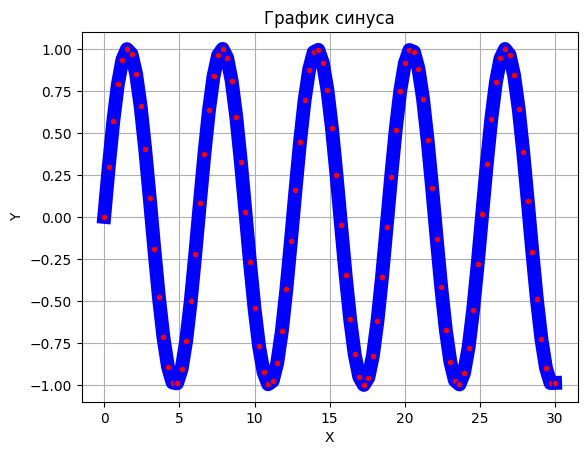

In [247]:
x = np.linspace(0, 30, 100)
y = np.sin(x)

# print(x,y)
plt.plot(x, y, color = 'blue', linewidth = 10, label = 'Синус', marker = 'o', markersize = 5, markerfacecolor = 'red')
plt.title('График синуса')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid()
plt.show()

Выше — простой линейный график на `matplotlib`. Дальше перейдём к **Titanic** и библиотеке `seaborn`.


**Столбчатая диаграмма.**

Сравним долю выживших по классу билета и полу:


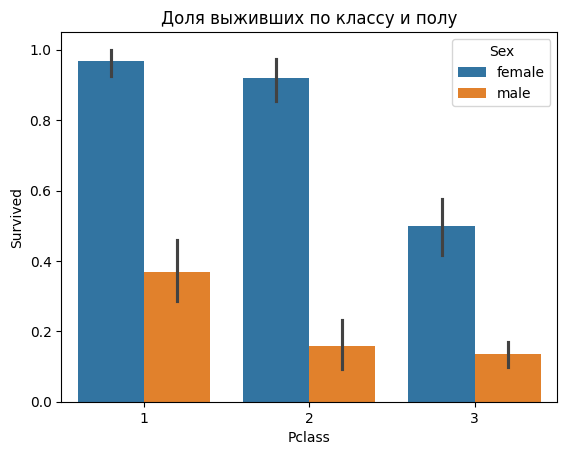

In [ ]:
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=titanic)
plt.title('Доля выживших по классу и полу')
plt.show()

**Box plot (ящик с усами).**

> 🔖 **Box plot** — график распределения числового признака. Показывает медиану, квартили и выбросы.

Посмотрим, как **возраст** пассажиров отличается в зависимости от **класса билета** и **пола**:


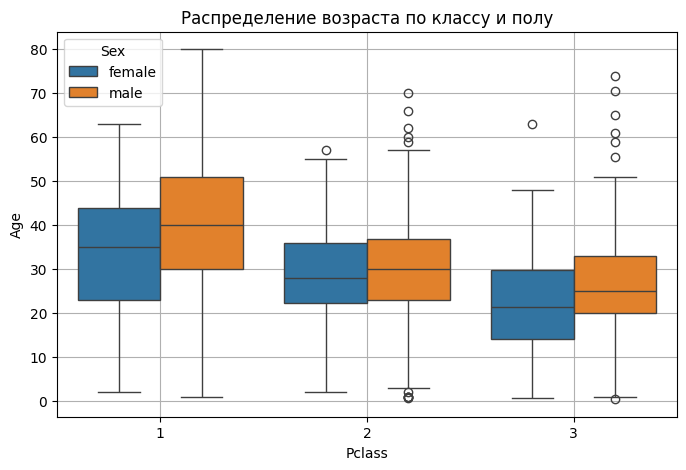

In [254]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Pclass', y='Age', hue='Sex', data=titanic)
plt.grid()
plt.title('Распределение возраста по классу и полу')
plt.show()

**Тепловая карта корреляций.**

Удобно увидеть связи между числовыми признаками «с первого взгляда»:


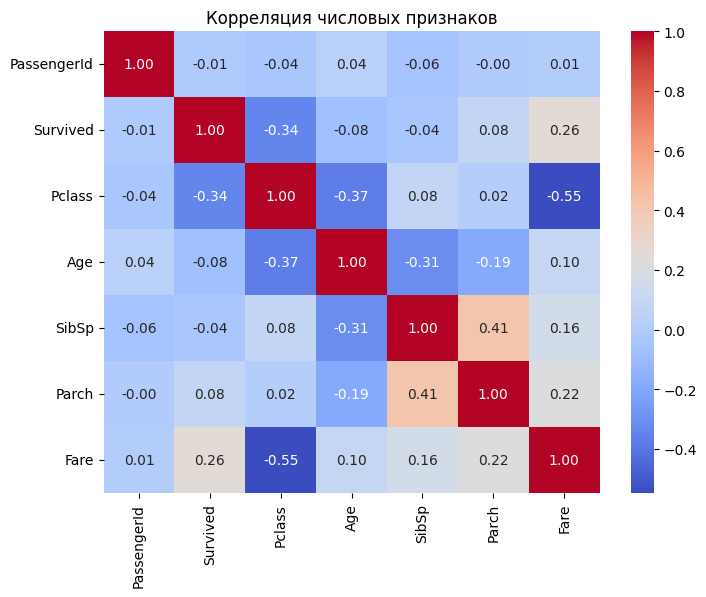

In [256]:
plt.figure(figsize=(8, 6))
sns.heatmap(titanic.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция числовых признаков')
plt.show()


**Точечная диаграмма (scatter plot).**

Ищем связь между возрастом и ценой билета. Цвет — пол пассажира:


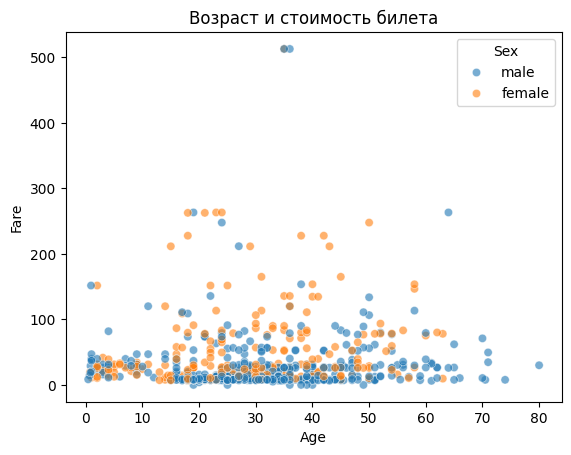

In [259]:
sns.scatterplot(x='Age', y='Fare', hue='Sex', data=titanic, alpha=0.6)
plt.title('Возраст и стоимость билета')
plt.show()


### **Итог.**

Сегодня мы:
- познакомились с массивами `numpy` и таблицами `pandas`
- научились смотреть на данные: `info`, `describe`, фильтрация, пропуски
- построили первые графики — в том числе **box plot**

---

*Made by Gordey Zuev.* @WhiteShape
